In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
X,y=make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

y=np.where(y==0,-1,1)

print(X.shape)
print(y.shape)
print("Classes",np.unique(y))


(200, 2)
(200,)
Classes [-1  1]


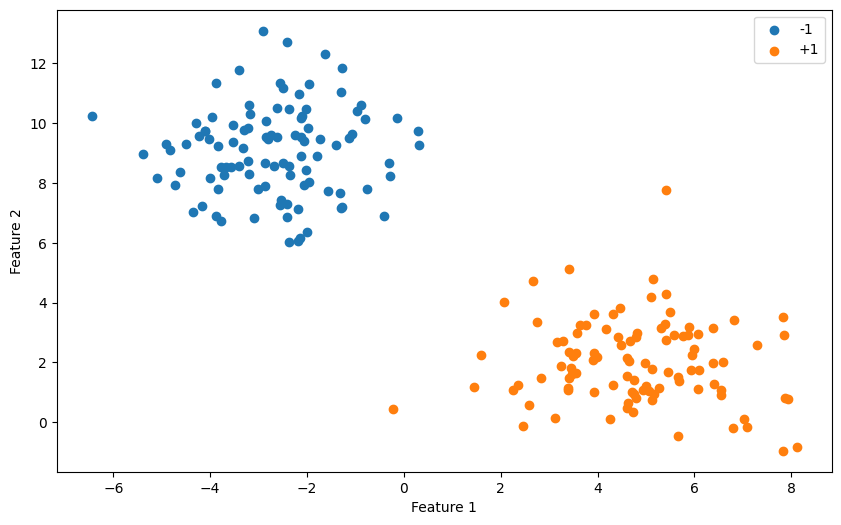

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    X[y==-1,0],
    X[y==-1,1],
    label="-1"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    label="+1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()




In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Set size",X_train.shape)
print("Test Set Size",X_test.shape)

Training Set size (150, 2)
Test Set Size (50, 2)


In [11]:
class SVM:
    def __init__(self,learning_rate=0.001,C=1.0,epochs=1000):
        self.lr=learning_rate
        self.C=C
        self.epochs=epochs

        self.w=None
        self.b=None

        self.loss_history=[]


    def fit(self,X,y):
        n_sample,n_features=X.shape
        self.w=np.zeros(n_features)
        self.b=0

        for epoch in range(self.epochs):

            scores=np.dot(X,self.w)+self.b

            margin=y*scores

            loss=np.maximum(0,1-margin)

            loss=(
                0.5*np.dot(self.w,self.w)
                +self.C*np.mean(loss)
            )

            self.loss_history.append(loss)
            mask=margin<1

            dw=self.w.copy()
            db=0

            if np.any(mask):
                dw-=self.C*np.sum(
                    y[mask,None]*X[mask],axis=0
                )
                db-=self.C*np.sum(y[mask])

            self.w-=self.lr*dw
            self.b-=self.lr*db

    def predict(self,X):
        scores=np.dot(X,self.w)+self.b
        return np.where(scores>=0,1,-1)


In [12]:
svm=SVM(
    learning_rate=0.001,
    C=1.0,
    epochs=1000
)

svm.fit(X_train,y_train)

In [13]:
print("Weights",svm.w)
print("Bias",svm.b)

Weights [ 0.48746976 -0.2816831 ]
Bias 1.125999999999993


In [14]:
y_pred=svm.predict(X_test)
print(y_pred)

[-1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1 -1 -1  1 -1  1  1 -1 -1  1 -1 -1
 -1  1  1  1  1  1  1  1  1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1
 -1 -1]


In [15]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",accuracy)

Accuracy 1.0


In [16]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[31  0]
 [ 0 19]]
